In [4]:
import xarray as xr
import numpy as np
import importlib.util
from pathlib import Path

#run from the repo root or Scripts directory
root = Path.cwd()
if root.name == 'Scripts':
    root = root.parent

#local plotting functions
spec = importlib.util.spec_from_file_location('plot_init', root / 'functions' / 'plot_init.py')
plot_init = importlib.util.module_from_spec(spec)
spec.loader.exec_module(plot_init)

#plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.tri as tri
import cartopy.feature as cfeature


In [5]:
#Monthly fields already averaged over years
fn = root / 'Data' / 'monthly_means.nc'
with xr.open_dataset(fn) as ds:
    data = ds.load()
lon = data['longitude'].values
lat = data['latitude'].values
elements = data['tri'].values


/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:

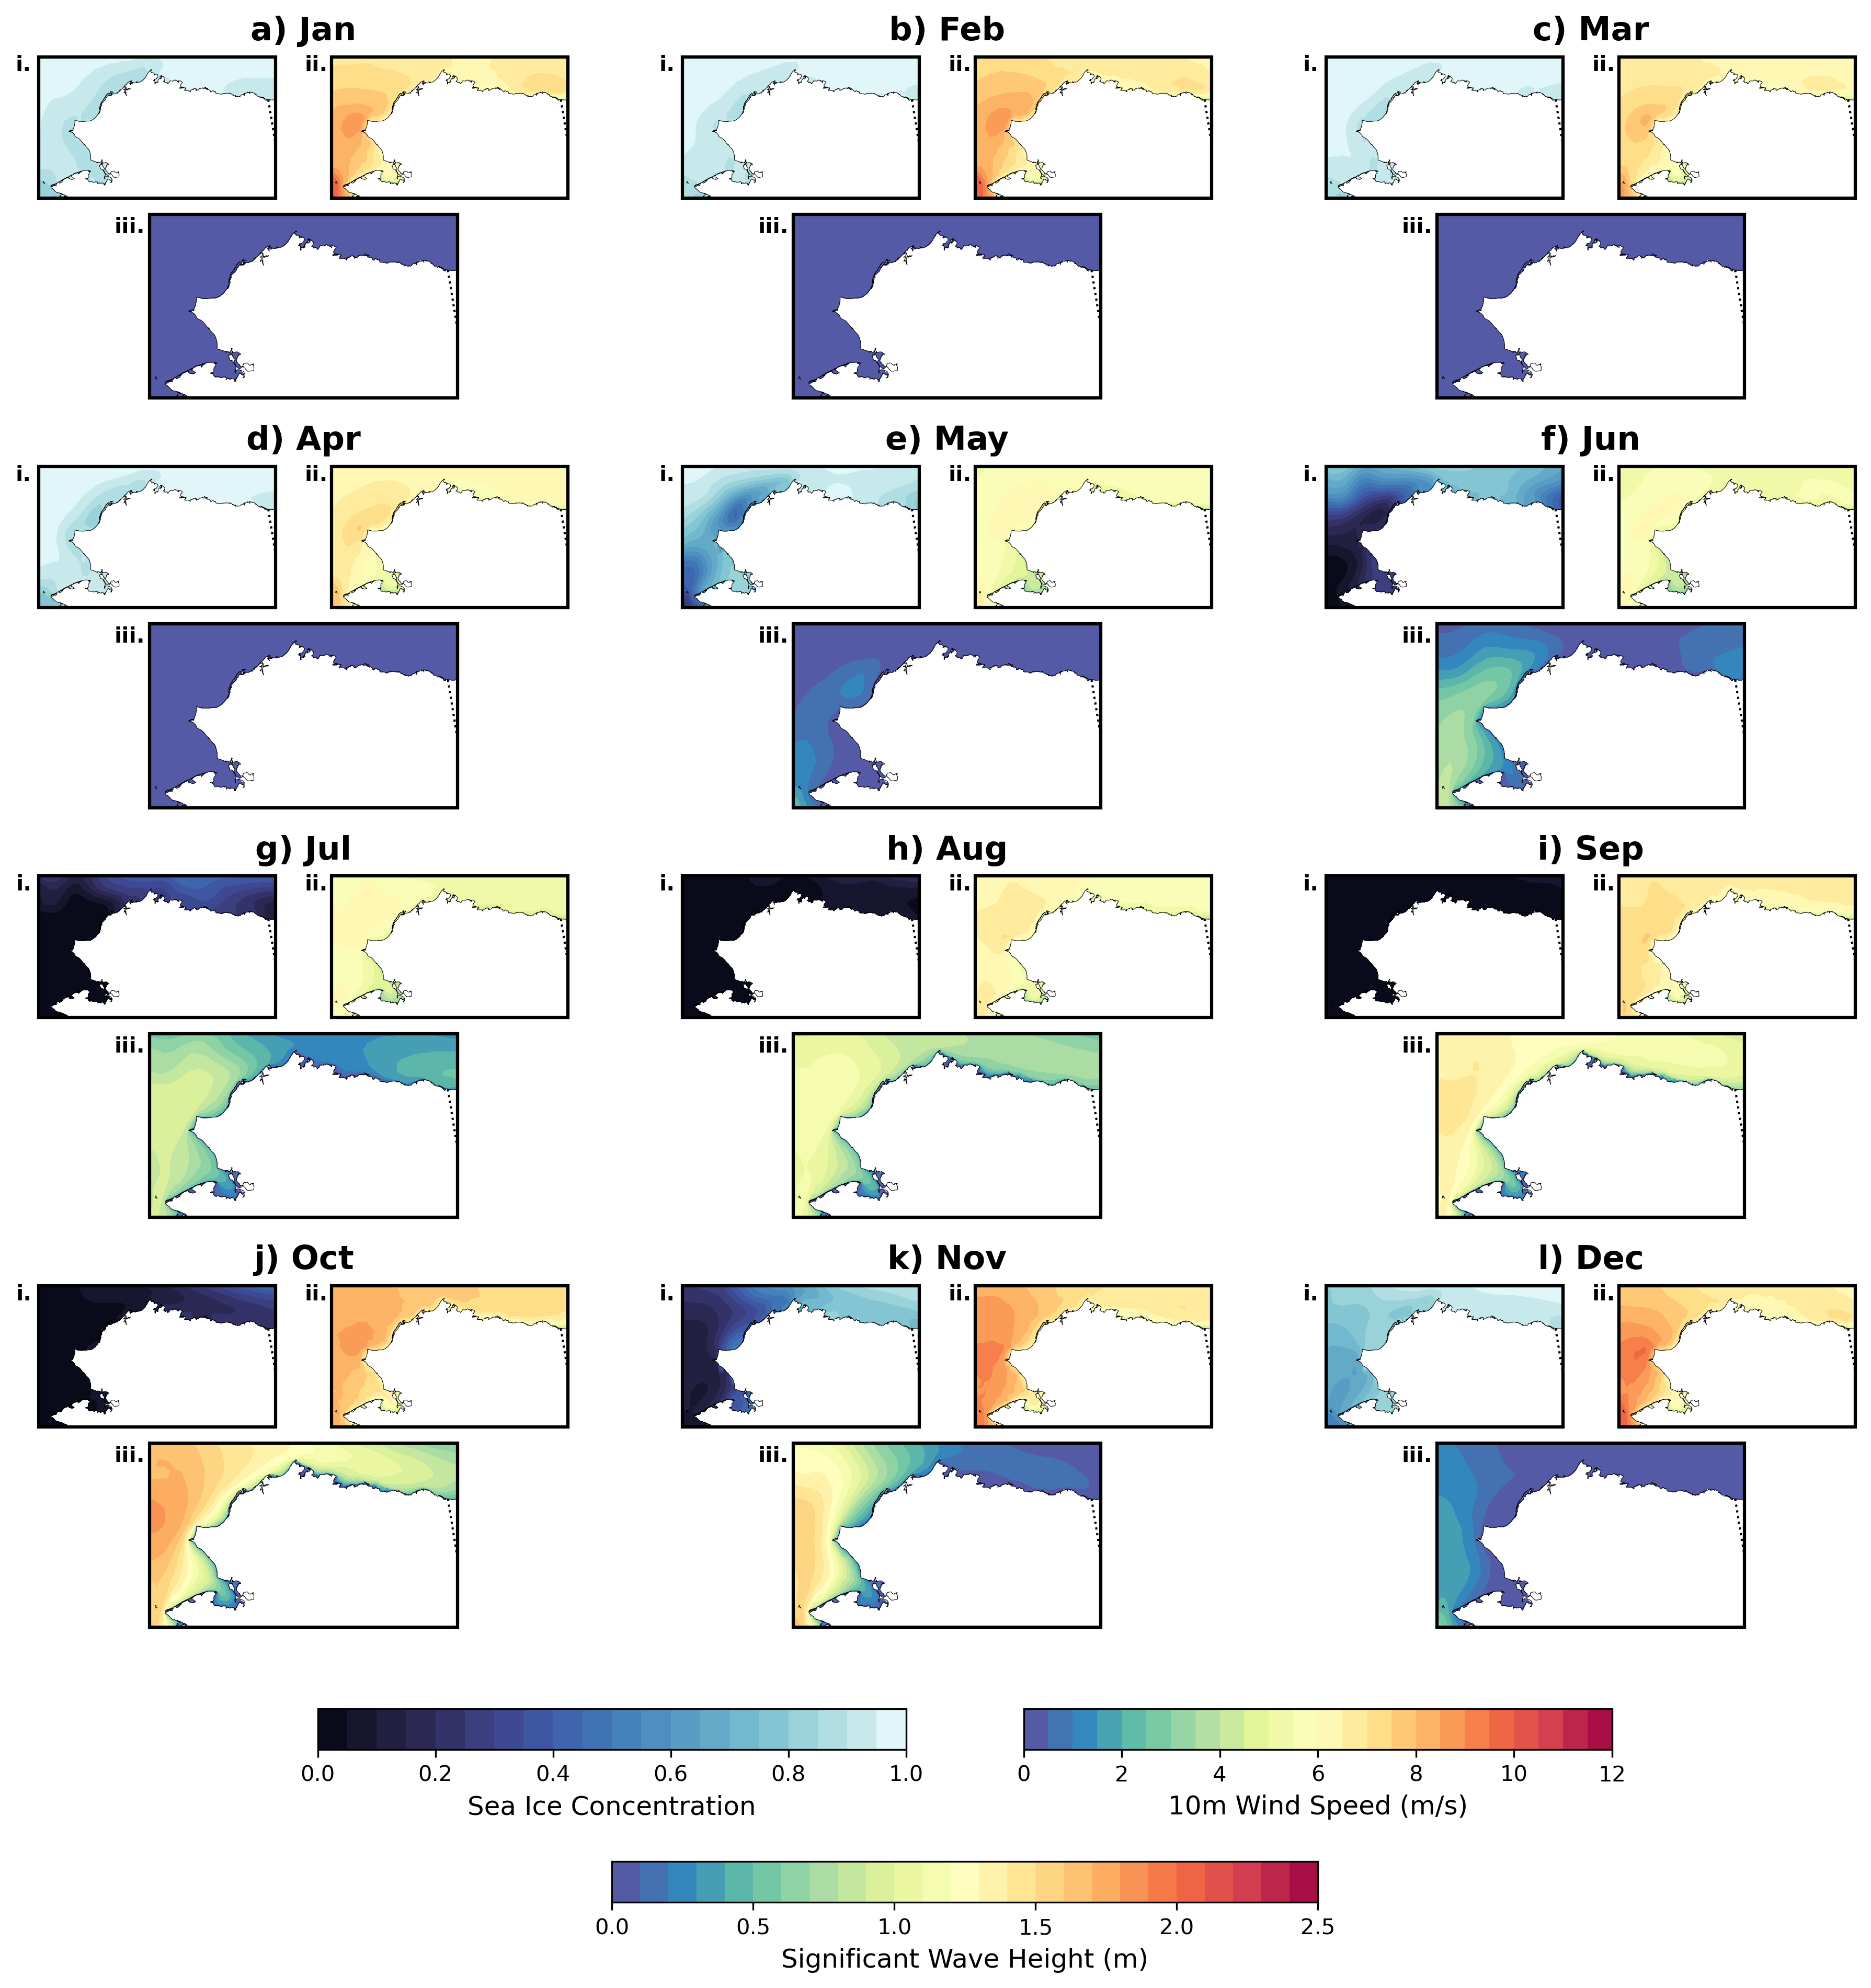

In [6]:
#initialize the plot and gridspec
fig = plt.figure(figsize=(15, 13),dpi=300)
proj0,akextent = plot_init.arctic_projection(option='alaska')
gs0 = gridspec.GridSpec(4, 3, figure=fig)

xnew, ynew, _ = proj0.transform_points(ccrs.PlateCarree(), lon, lat).T  #project the lon/lat to the map projection
triang = tri.Triangulation(xnew,ynew, triangles=elements-1)

var_levels = {
    'hs': np.arange(0,2.6,0.1),
    'ice': np.arange(0,1.05,0.05),
    'wnd': np.arange(0,12.5,0.5)
}
var_cmaps = {
    'hs': sns.color_palette("Spectral_r", as_cmap=True),
    'ice': cmocean.cm.ice,
    'wnd': sns.color_palette("Spectral_r", as_cmap=True)
}

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov', 'Dec']
monthi = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
monthlabel = ['a','b','c','d','e','f','g','h','i','j','k','l']

def make_it_nice(ax,extent):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=0.25,zorder=4)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1,zorder=4)

for i,month in enumerate(months):
    subgs = gridspec.GridSpecFromSubplotSpec(2,2, subplot_spec=gs0[i], height_ratios=[1,1.3],hspace=0.1)
    iceax = fig.add_subplot(subgs[0,0], projection=proj0)
    wndax = fig.add_subplot(subgs[0,1], projection=proj0)
    hsax = fig.add_subplot(subgs[1,:], projection=proj0)
    make_it_nice(iceax,akextent)
    make_it_nice(wndax,akextent)
    make_it_nice(hsax,akextent)

    #select the monthly means
    ice_seas = data['ice'].sel(month=monthi[month]).values
    wnd_seas = data['wnd'].sel(month=monthi[month]).values
    hs_seas = data['hs'].sel(month=monthi[month]).values

    ice_seas = np.where(np.isnan(ice_seas), 0, ice_seas)
    wnd_seas = np.where(np.isnan(wnd_seas), 0, wnd_seas)
    hs_seas = np.where(np.isnan(hs_seas), 0, hs_seas)

    #plot the data
    ice_cf = iceax.tricontourf(triang, ice_seas, levels=var_levels['ice'], cmap=var_cmaps['ice'])
    wnd_cf = wndax.tricontourf(triang, wnd_seas, levels=var_levels['wnd'], cmap=var_cmaps['wnd'])
    hs_cf = hsax.tricontourf(triang, hs_seas, levels=var_levels['hs'], cmap=var_cmaps['hs'])

    #Add labels i-iii
    iceax.text(-0.065, 0.90, 'i.', transform = iceax.transAxes, fontsize=10, fontweight='bold', ha='center')
    wndax.text(-0.065, 0.90, 'ii.', transform = wndax.transAxes, fontsize=10, fontweight='bold', ha='center')
    hsax.text(-0.065, 0.90, 'iii.', transform = hsax.transAxes, fontsize=10, fontweight='bold', ha='center')

    
    #Add text identifying the month
    hsax.text(0.5, 1.95, f'{monthlabel[i]}) {month}', transform = hsax.transAxes, fontsize=15, fontweight='bold', ha='center')
    #place a box around the subplot
    for ax in [iceax, wndax, hsax]:
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)

xorg,yorg,xlen,ylen = 0.245,0.05,0.25,0.02
cbar_sic = fig.add_axes([xorg,yorg,xlen,ylen])
cbar = plt.colorbar(ice_cf, cax=cbar_sic, orientation='horizontal')
ticklevels = np.arange(0,1.1,0.2)
cbar.ax.set_xticks(ticklevels)
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_xlabel('Sea Ice Concentration', fontsize=12)


cbar_wnd = fig.add_axes([xorg+xlen+0.05,yorg,xlen,ylen])
cbar = plt.colorbar(wnd_cf, cax=cbar_wnd, orientation='horizontal')
ticklevels = np.arange(0,13,2)
cbar.ax.set_xticks(ticklevels)
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_xlabel('10m Wind Speed (m/s)', fontsize=12)

cbar_hs = fig.add_axes([xorg+(0.5*xlen),yorg-0.075,xlen+0.05,ylen])
cbar = plt.colorbar(hs_cf, cax=cbar_hs, orientation='horizontal')
ticklevels = np.arange(0,3,0.5)
cbar.ax.set_xticks(ticklevels)
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_xlabel('Significant Wave Height (m)', fontsize=12)

plt.savefig(root / 'Figures' / 'monthly_means.png',bbox_inches='tight')